# Decoding NTSC Color from Analog FPV Video

## Overview

In a [previous post](https://github.com/DaulPavid/notebooks/blob/master/ntsc_video_drones/decoding_drone_ntsc_video.ipynb) I walked through extracting a grayscale image from an analog FPV drone capture using a HackRF and Python. That post stopped at luminance. But NTSC packs color into the same composite signal via a QAM-modulated subcarrier at 3.58 MHz.

This post picks up where that one left off: comb filtering for Y/C separation, burst phase extraction, quadrature demodulation, and the YIQ-to-RGB matrix. Everything applies directly to real SDR captures.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve
import warnings; warnings.filterwarnings('ignore')

%matplotlib inline

## NTSC Timing and Color Parameters

The key constant is the subcarrier frequency: $f_{sc} = 3{,}579{,}545$ Hz. Its ratio to the line rate is exactly $227.5$, so the subcarrier flips phase between adjacent lines. That's the property the comb filter exploits.

In [2]:
SAMPLE_RATE       = 16.0e6
SUBCARRIER_FREQ   = 3_579_545.0
LINE_DURATION_US  = 63.556
HSYNC_DURATION_US = 4.7
BACK_PORCH_US     = 4.7
FRONT_PORCH_US    = 1.5

SAMPLES_PER_LINE = int(SAMPLE_RATE * LINE_DURATION_US * 1e-6)
SYNC_END         = int(SAMPLE_RATE * HSYNC_DURATION_US * 1e-6)
ACTIVE_START     = SYNC_END + int(SAMPLE_RATE * BACK_PORCH_US * 1e-6)
ACTIVE_END       = SAMPLES_PER_LINE - int(SAMPLE_RATE * FRONT_PORCH_US * 1e-6)
ACTIVE_WIDTH     = ACTIVE_END - ACTIVE_START
BURST_START      = SYNC_END + int(SAMPLE_RATE * 0.6e-6)
BURST_END        = BURST_START + int(SAMPLE_RATE * 9.0 / SUBCARRIER_FREQ)
PHASE_INCREMENT  = (2.0 * np.pi * SUBCARRIER_FREQ) / SAMPLE_RATE
CHROMA_GAIN      = 0.4

LINES_PER_FIELD = 263
VBLANK_LINES    = 21
PRE_EQ_LINES    = 3
VSYNC_LINES     = 3

SYNC_TIP  = 0.0
BLANKING  = 0.285
BLACK     = 0.285
WHITE     = 1.0
BURST_AMP = 0.143

print(f"{SAMPLES_PER_LINE} samples/line, active: {ACTIVE_START}-{ACTIVE_END} ({ACTIVE_WIDTH} px)")

1016 samples/line, active: 150-992 (842 px)


## Color Bars in YIQ

NTSC transmits color as $I$ and $Q$, modulated onto the subcarrier. The bars are defined in RGB and converted:

$$I = 0.596R - 0.274G - 0.322B, \quad Q = 0.211R - 0.523G + 0.312B$$

In [3]:
RGB_TO_YIQ = np.array([[ 0.299,  0.587,  0.114],
                      [ 0.596, -0.274, -0.322],
                      [ 0.211, -0.523,  0.312]])

YIQ_TO_RGB = np.array([[1.000,  0.956,  0.621],
                       [1.000, -0.272, -0.647],
                       [1.000, -1.106,  1.703]])

BAR_RGB = [(1,1,1),(1,1,0),(0,1,1),(0,1,0),(1,0,1),(1,0,0),(0,0,1),(0,0,0)]
BAR_NAMES = ['White','Yellow','Cyan','Green','Magenta','Red','Blue','Black']
COLOR_BARS = [tuple(RGB_TO_YIQ @ np.array(rgb)) for rgb in BAR_RGB]

## Generating the Composite Signal

Each active sample encodes color as QAM:

$$s[n] = \mathrm{BLACK} + Y(W{-}B) + 0.4\left(I\cos\varphi_n + Q\sin\varphi_n\right)$$


In [4]:
def generate_ntsc_field(bars=None, add_noise=False, noise_std=0.01):
    if bars is None:
        bars = COLOR_BARS

    total = LINES_PER_FIELD * SAMPLES_PER_LINE
    out = np.full(total, BLANKING, dtype=np.float64)

    for line in range(LINES_PER_FIELD):
        off = line * SAMPLES_PER_LINE
        vblank = line < VBLANK_LINES
        vsync  = PRE_EQ_LINES <= line < PRE_EQ_LINES + VSYNC_LINES
        phase  = (line * np.pi) % (2 * np.pi)

        for s in range(SAMPLES_PER_LINE):
            if s < SYNC_END:
                if vsync:
                    out[off+s] = SYNC_TIP if s < SAMPLES_PER_LINE - SYNC_END else BLANKING
                else:
                    out[off+s] = SYNC_TIP
            elif BURST_START <= s < BURST_END:
                out[off+s] = BLANKING + BURST_AMP * np.cos(phase)
            elif ACTIVE_START <= s < ACTIVE_END and not vblank:
                x = s - ACTIVE_START
                y, i, q = bars[min(x * 8 // ACTIVE_WIDTH, 7)]
                chroma = i * np.cos(phase) + q * np.sin(phase)
                out[off+s] = np.clip(BLACK + y * (WHITE - BLACK) + chroma * CHROMA_GAIN, 0, 1)

            phase += PHASE_INCREMENT
            if phase >= 2 * np.pi:
                phase -= 2 * np.pi

    return out

composite = generate_ntsc_field()

A single active line shows the sync pulse, burst, and chroma subcarrier riding on the luma steps:

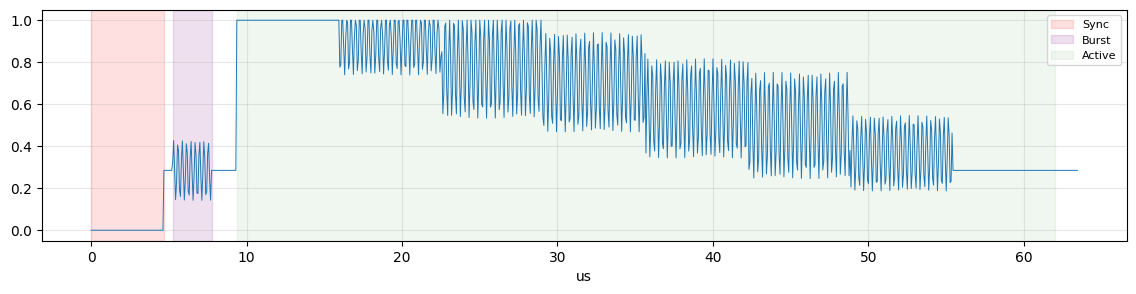

In [5]:
s0 = 30 * SAMPLES_PER_LINE
t = np.arange(SAMPLES_PER_LINE) / SAMPLE_RATE * 1e6

plt.figure(figsize=(14, 3))
plt.plot(t, composite[s0:s0+SAMPLES_PER_LINE], lw=0.7)
plt.axvspan(0, HSYNC_DURATION_US, alpha=0.12, color='red', label='Sync')
plt.axvspan(BURST_START/SAMPLE_RATE*1e6, BURST_END/SAMPLE_RATE*1e6, alpha=0.12, color='purple', label='Burst')
plt.axvspan(ACTIVE_START/SAMPLE_RATE*1e6, ACTIVE_END/SAMPLE_RATE*1e6, alpha=0.06, color='green', label='Active')
plt.xlabel('us'); plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.show()

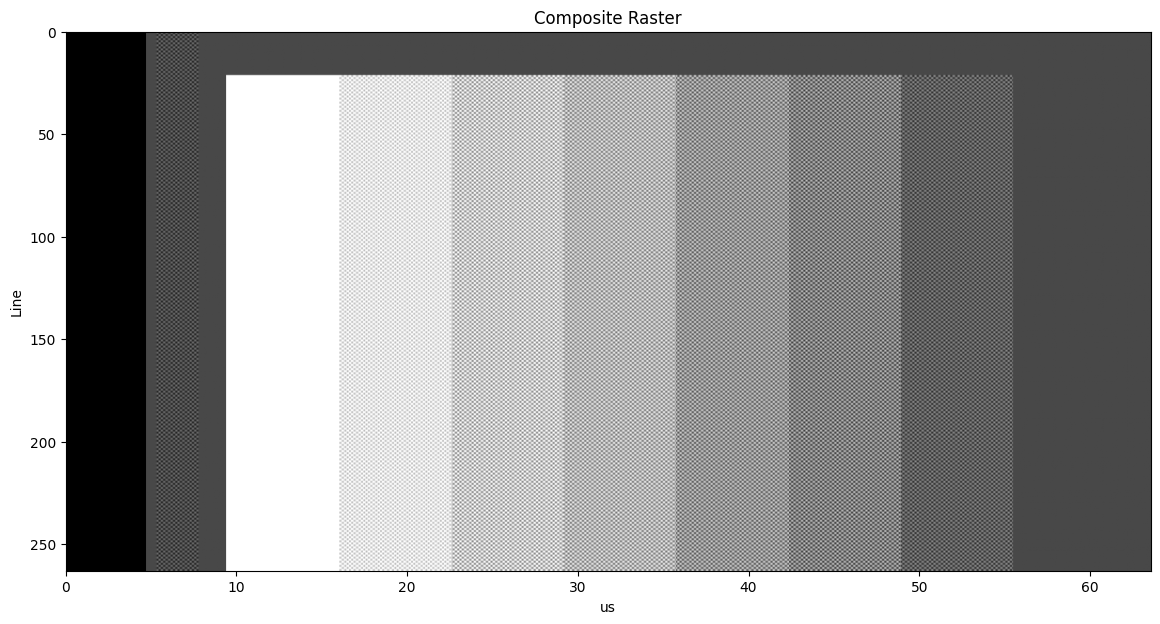

In [6]:
plt.figure(figsize=(14, 7))
plt.imshow(composite.reshape(LINES_PER_FIELD, SAMPLES_PER_LINE), aspect='auto', cmap='gray',
           vmin=0, vmax=1, extent=[0, LINE_DURATION_US, LINES_PER_FIELD, 0])
plt.title('Composite Raster'); plt.xlabel('us'); plt.ylabel('Line')
plt.show()

## Sync Detection and Line Extraction

Same approach as the previous post. Threshold below 0.1 for sync edges, extract lines, sample the back porch for per-line black level:

In [7]:
def detect_and_extract(signal):
    # Find rising edges of composite sync
    is_sync = signal < 0.1
    edges = []
    for i in range(1, len(is_sync)):
        if is_sync[i] and not is_sync[i - 1]:
            edges.append(i)

    # Back porch sampling window
    bp_start = SYNC_END + int(SAMPLE_RATE * 0.5e-6)
    bp_end   = bp_start + int(SAMPLE_RATE * 1.2e-6)

    lines = []
    black_levels = []
    for edge in edges:
        if edge + SAMPLES_PER_LINE <= len(signal):
            line = signal[edge : edge + SAMPLES_PER_LINE]
            lines.append(line)
            black_levels.append(np.mean(line[bp_start:bp_end]))

    return np.array(lines), np.array(black_levels)

lines, black_levels = detect_and_extract(composite)

# Find active lines (ones with actual video content above black)
active_idx = []
for i in range(len(lines)):
    if np.max(lines[i, ACTIVE_START:ACTIVE_END]) > BLACK + 0.05:
        active_idx.append(i)
active_idx = np.array(active_idx)

print(f"{len(lines)} lines, {len(active_idx)} active")

262 lines, 242 active


## Burst Phase Extraction

The color burst is a ~9-cycle reference in the back porch (5.5 to 7.7 us). We measure its phase with quadrature correlation:

$$\phi = \text{atan2}\!\left(-\sum s[n]\sin\theta_n,\;\sum s[n]\cos\theta_n\right)$$

Since we enforce 227.5 cycles/line, the burst alternates between ~0 and ~$\pi$ on adjacent lines. The decoder handles this automatically because each line's measured phase reconstructs that line's carrier.

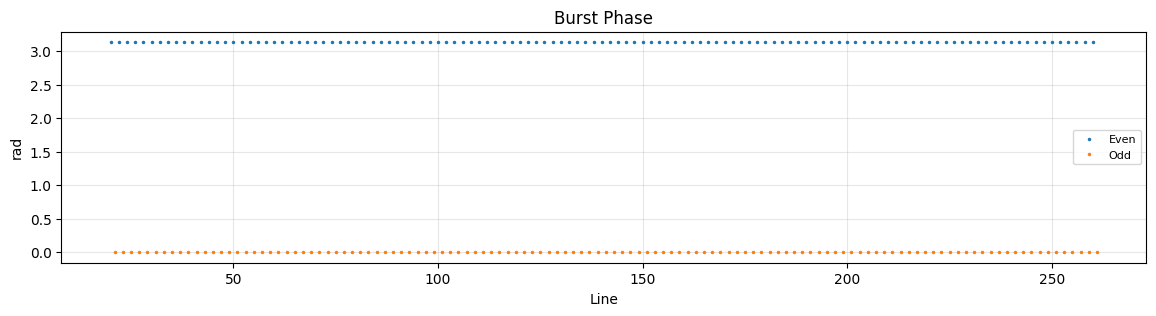

In [8]:
def extract_burst_phase(lines):
    bs = int(5.5e-6 * SAMPLE_RATE)
    be = int(7.7e-6 * SAMPLE_RATE)
    n = np.arange(bs, be)
    theta = 2 * np.pi * (SUBCARRIER_FREQ / SAMPLE_RATE) * n
    cos_ref = np.cos(theta)
    sin_ref = np.sin(theta)

    phases = np.zeros(len(lines))
    for i in range(len(lines)):
        seg = lines[i][bs:be]
        if len(seg) == len(cos_ref):
            i_acc = np.sum(seg * cos_ref)
            q_acc = -np.sum(seg * sin_ref)
            phases[i] = np.arctan2(q_acc, i_acc)

    return phases

burst_phases = extract_burst_phase(lines)

even = active_idx[active_idx % 2 == 0]
odd  = active_idx[active_idx % 2 == 1]
plt.figure(figsize=(14, 3))
plt.plot(even, burst_phases[even], '.', ms=3, label='Even')
plt.plot(odd,  burst_phases[odd],  '.', ms=3, label='Odd')
plt.title('Burst Phase'); plt.ylabel('rad'); plt.xlabel('Line')
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.show()

## Y/C Separation with a Comb Filter

Because the subcarrier flips phase every line, adding adjacent lines cancels chroma (leaving luma) and subtracting cancels luma (leaving chroma):

$$Y = 0.25 L_{-1} + 0.50 L_0 + 0.25 L_{+1}, \quad C = -0.25 L_{-1} + 0.50 L_0 - 0.25 L_{+1}$$

In [9]:
def comb_filter(lines):
    luma   = np.zeros_like(lines)
    chroma = np.zeros_like(lines)

    for i in range(1, len(lines) - 1):
        luma[i]   =  0.25 * lines[i-1] + 0.50 * lines[i] + 0.25 * lines[i+1]
        chroma[i] = -0.25 * lines[i-1] + 0.50 * lines[i] - 0.25 * lines[i+1]

    luma[0]  = lines[0]
    luma[-1] = lines[-1]
    return luma, chroma

luma, chroma = comb_filter(lines)

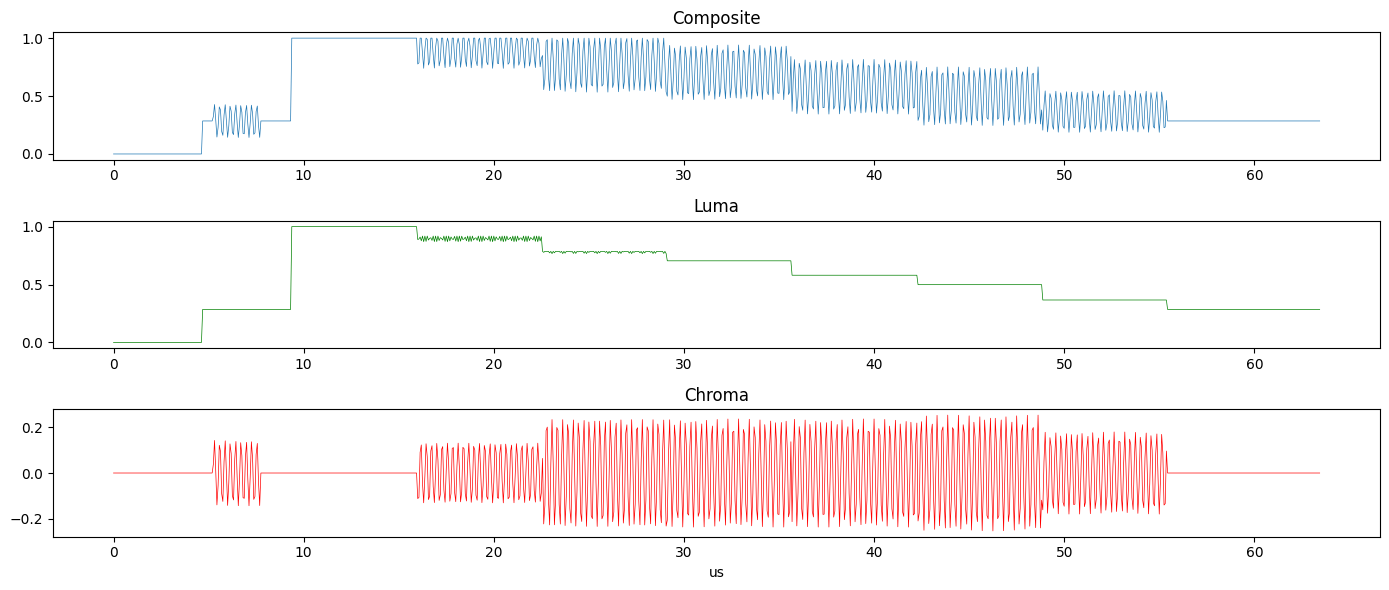

In [10]:
dl = active_idx[len(active_idx) // 2]
t = np.arange(SAMPLES_PER_LINE) / SAMPLE_RATE * 1e6

fig, axes = plt.subplots(3, 1, figsize=(14, 6))
axes[0].plot(t, lines[dl], lw=0.5); axes[0].set_title('Composite')
axes[1].plot(t, luma[dl], lw=0.5, color='green'); axes[1].set_title('Luma')
axes[2].plot(t, chroma[dl], lw=0.5, color='red'); axes[2].set_title('Chroma')
axes[2].set_xlabel('us')
plt.tight_layout(); plt.show()

## QAM Demodulation

We recover $I$ and $Q$ by multiplying the chroma by cos/sin carriers and low-pass filtering:

$$C \cdot \cos(\omega t + \phi) \;\xrightarrow{\text{LPF}}\; \tfrac{I}{2}$$

NTSC uses separate FIR filters: I at ~1.5 MHz (13 taps, some negative) and Q at ~0.5 MHz (13 taps, all positive). The gain factor was empirically tuned to recover full-scale I/Q values from the composite.

In [11]:
I_TAPS = np.array([-0.00197639,-0.00677500, 0.00000000, 0.04209215, 0.12522205,
                    0.21458776, 0.25369887, 0.21458776, 0.12522205, 0.04209215,
                    0.00000000,-0.00677500,-0.00197639])

Q_TAPS = np.array([ 0.00380492, 0.01781726, 0.04418890, 0.08103522, 0.12053787,
                    0.15121291, 0.16280584, 0.15121291, 0.12053787, 0.08103522,
                    0.04418890, 0.01781726, 0.00380492])

DEMOD_GAIN = 2.0 / CHROMA_GAIN

def demodulate_iq(chroma, burst_phases, active_idx):
    I_out = np.zeros_like(chroma)
    Q_out = np.zeros_like(chroma)
    sc_norm = SUBCARRIER_FREQ / SAMPLE_RATE
    x = np.arange(chroma.shape[1])

    for li in active_idx:
        carrier = burst_phases[li] + 2 * np.pi * sc_norm * x
        I_out[li] = np.convolve(chroma[li] * np.cos(carrier) * DEMOD_GAIN, I_TAPS, mode='same')
        Q_out[li] = np.convolve(chroma[li] * np.sin(carrier) * DEMOD_GAIN, Q_TAPS, mode='same')

    return I_out, Q_out

I_ch, Q_ch = demodulate_iq(chroma, burst_phases, active_idx)

## YIQ to RGB

Normalize luma with the per-line black level, then apply the color matrix:

$$\begin{bmatrix}R\\G\\B\end{bmatrix} = \begin{bmatrix}1 & 0.956 & 0.621\\1 & -0.272 & -0.647\\1 & -1.106 & 1.703\end{bmatrix}\begin{bmatrix}Y\\I\\Q\end{bmatrix}$$

In [12]:
def decode_rgb(luma, I_ch, Q_ch, black_levels, active_idx):
    width = ACTIVE_END - ACTIVE_START
    rgb = np.zeros((len(active_idx), width, 3))

    for idx, li in enumerate(active_idx):
        Y = np.clip((luma[li, ACTIVE_START:ACTIVE_END] - black_levels[li]) / 0.7, 0, 1)
        I = I_ch[li, ACTIVE_START:ACTIVE_END]
        Q = Q_ch[li, ACTIVE_START:ACTIVE_END]

        for x in range(width):
            yiq = np.array([Y[x], I[x], Q[x]])
            rgb[idx, x] = YIQ_TO_RGB @ yiq

    return np.clip(rgb, 0, 1)

rgb_image = decode_rgb(luma, I_ch, Q_ch, black_levels, active_idx)

Decoded color bars:

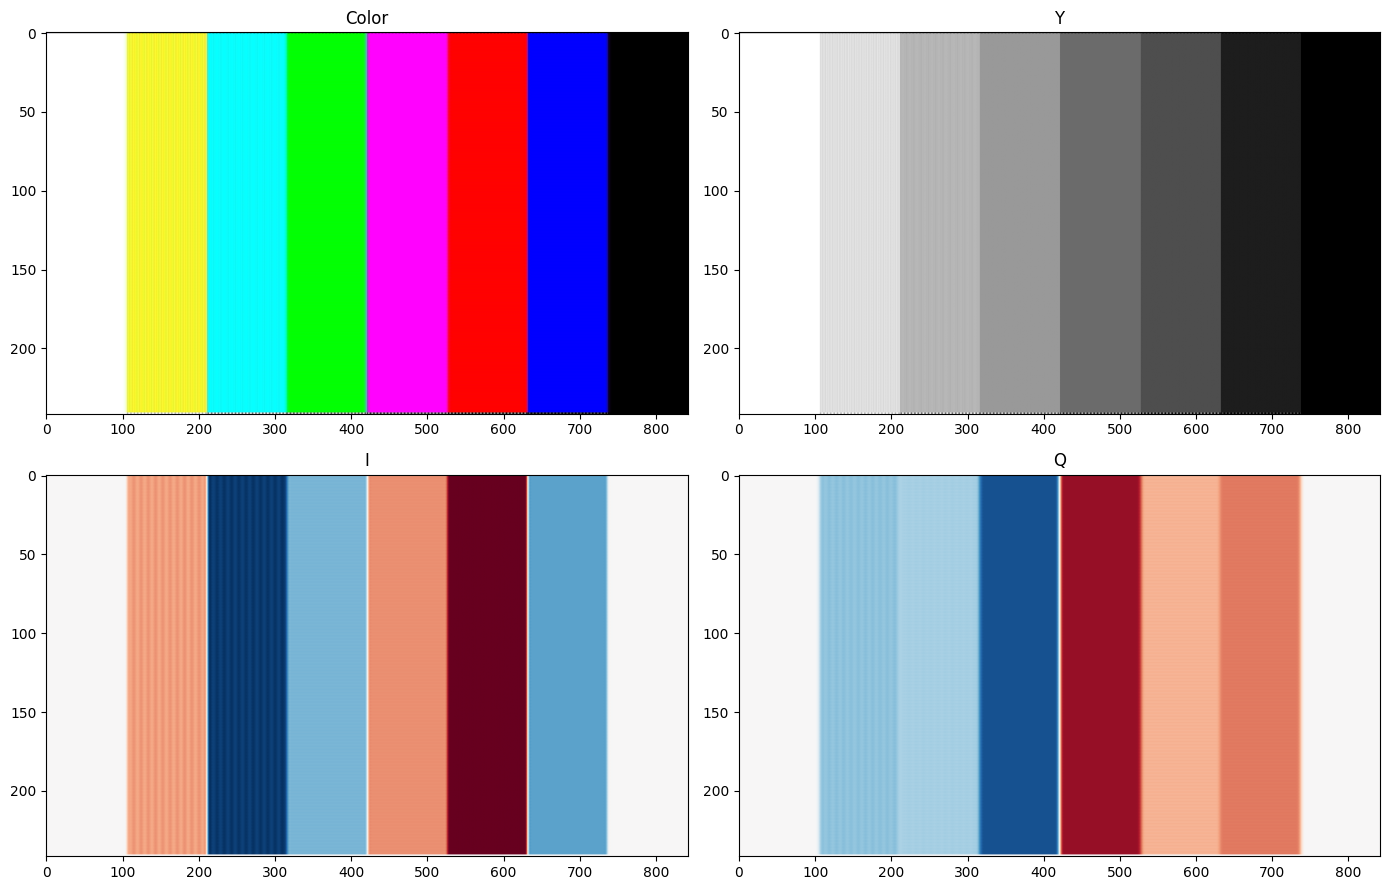

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

Y_img = np.zeros((len(active_idx), ACTIVE_WIDTH))
for idx, li in enumerate(active_idx):
    Y_img[idx] = np.clip((luma[li, ACTIVE_START:ACTIVE_END] - black_levels[li]) / 0.7, 0, 1)

axes[0,0].imshow(rgb_image, aspect='auto')
axes[0,0].set_title('Color')
axes[0,1].imshow(Y_img, aspect='auto', cmap='gray', vmin=0, vmax=1)
axes[0,1].set_title('Y')
axes[1,0].imshow(I_ch[active_idx][:, ACTIVE_START:ACTIVE_END], aspect='auto', cmap='RdBu_r', vmin=-0.6, vmax=0.6)
axes[1,0].set_title('I')
axes[1,1].imshow(Q_ch[active_idx][:, ACTIVE_START:ACTIVE_END], aspect='auto', cmap='RdBu_r', vmin=-0.6, vmax=0.6)
axes[1,1].set_title('Q')

plt.tight_layout(); plt.show()

## Connecting to Real Captures

To use this on actual SDR captures, plug in the front-end from the previous post:

In [14]:
def fm_demod(iq):
    return np.angle(iq[1:] * np.conj(iq[:-1]))

def iir_lowpass(sig, fc=2e6, fs=SAMPLE_RATE):
    a = (2 * np.pi * fc) / (fs + 2 * np.pi * fc)
    out = np.zeros_like(sig)
    out[0] = a * sig[0]
    for i in range(1, len(sig)):
        out[i] = a * sig[i] + (1 - a) * out[i - 1]
    return out

def sync_tip_clamp(sig, fs=SAMPLE_RATE, tau=0.02):
    a = 1 - np.exp(-1 / (fs * tau))
    out = np.zeros_like(sig)
    tip = sig[0]
    for i in range(len(sig)):
        if sig[i] < tip:
            tip = sig[i]
        else:
            tip *= (1 - a)
        out[i] = sig[i] - max(tip, -5.0)
    return out

The full chain:

```python
iq = np.fromfile('capture.cf32', dtype=np.complex64)
composite = sync_tip_clamp(iir_lowpass(fm_demod(iq)))
rgb = full_pipeline(composite)
```

If colors look rotated, add a phase offset to the carrier reconstruction in `demodulate_iq`.

## Applying the Pipeline to a Real Capture

Load the capture, FM-demodulate, low-pass and clamp the sync tip, and rescale onto the same `[0, 1]` axis as the synthetic composite. Then run every stage of the color-bar pipeline on the result, one cell at a time, with a sync state machine that handles VSYNC broad pulses and equalising pulses so they don't get treated as line starts.

In [15]:
from scipy.io import wavfile
from scipy.signal import lfilter, butter
from scipy import signal

sr, data = wavfile.read('../data/fm_baseband_5864000000Hz.wav', mmap=True)
assert sr == int(SAMPLE_RATE), f'capture is {sr} Hz; expected {int(SAMPLE_RATE)} Hz'
chunk = data[int(sr * 0.5) : int(sr * 0.5) + int(sr * 0.3)]
iq = (chunk[:, 0].astype(np.float32) + 1j * chunk[:, 1].astype(np.float32)).astype(np.complex64)

demod = fm_demod(iq)
demod = np.clip(demod, *np.percentile(demod, [0.5, 99.5]))
b, a = butter(4, 4.5e6 / (SAMPLE_RATE / 2), btype='low')
demod = lfilter(b, a, demod)

composite = sync_tip_clamp(demod)
composite = composite / np.percentile(composite, 99.5)
print(f'composite: {len(composite):,} samples ({len(composite)/SAMPLE_RATE*1e3:.1f} ms at {SAMPLE_RATE/1e6:.0f} MSPS)')

composite: 4,799,999 samples (300.0 ms at 16 MSPS)


### Sync State Machine

Two pieces from the reference doc:

- **HSYNC two-stage trigger**: rising edges of `csync = composite < 0.1`, debounced by a 60 us holdoff so equalising pulses (~31.78 us spacing) and broad-pulse halves can't double-trigger.
- **VSYNC integrator**: a single-pole IIR low-pass over `csync` with `tau = 100 us`, thresholded at `0.35`. Normal HSYNC (4.7 us out of 63.55 us) keeps the integrator below threshold; VSYNC's broad pulses pin it high. HSYNC edges that land inside a VSYNC interval are dropped.

18 VSYNC intervals; field starts at sample 156018; 263 lines retained for one-field walkthrough


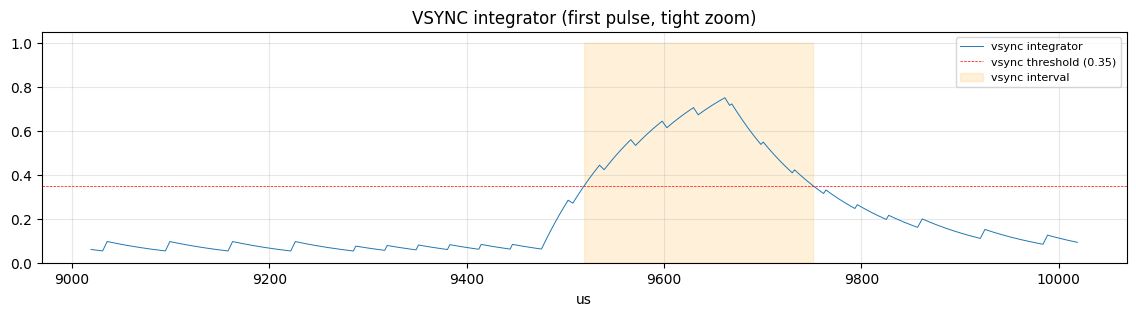

In [16]:
from enum import IntEnum

class HsyncState(IntEnum):
    READY   = 0
    HOLDOFF = 1

def detect_and_extract_capture(signal, fs=SAMPLE_RATE,
                                 sync_threshold=0.1,
                                 vsync_tau=100e-6, vsync_threshold=0.35,
                                 hsync_holdoff=60e-6):
    csync = (signal < sync_threshold).astype(np.float32)

    # VSYNC integrator
    alpha = 1.0 - np.exp(-1.0 / (fs * vsync_tau))
    integ = lfilter([alpha], [1.0, -(1.0 - alpha)], csync)
    vsync = integ > vsync_threshold

    # HSYNC trigger with holdoff
    holdoff_samples = int(hsync_holdoff * fs)
    rising_indices  = np.where(np.diff(csync.astype(np.int8)) > 0)[0] + 1
    state, holdoff_end, edges = HsyncState.READY, 0, []
    for n in rising_indices:
        if state == HsyncState.HOLDOFF and n >= holdoff_end:
            state = HsyncState.READY
        if state == HsyncState.READY:
            if not vsync[n]:
                edges.append(int(n))
            state = HsyncState.HOLDOFF
            holdoff_end = n + holdoff_samples

    edges = np.array(edges, dtype=int)
    edges = edges[(edges > 0) & (edges + SAMPLES_PER_LINE <= len(signal))]

    # Sub-sample HSYNC alignment via linear interp on the threshold crossing
    fracs = (signal[edges - 1] - sync_threshold) / (signal[edges - 1] - signal[edges])
    fracs = np.clip(fracs, 0.0, 1.0)
    lines = np.empty((len(edges), SAMPLES_PER_LINE), dtype=signal.dtype)
    for i, (e, f) in enumerate(zip(edges, fracs)):
        lines[i] = (1.0 - f) * signal[e-1:e-1+SAMPLES_PER_LINE] + f * signal[e:e+SAMPLES_PER_LINE]

    bp_start = SYNC_END + int(fs * 0.5e-6)
    bp_end   = bp_start + int(fs * 1.2e-6)
    black_levels = np.array([np.mean(ln[bp_start:bp_end]) for ln in lines])
    return lines, black_levels, edges, vsync, integ

# Full unfiltered output for multi-field averaging; trimmed copies for the per-field walkthrough.
all_lines, all_black_levels, all_hsync_edges, vsync_mask, vsync_integ = detect_and_extract_capture(composite)

vsync_starts  = np.where(np.diff(vsync_mask.astype(np.int8)) > 0)[0] + 1
vsync_falling = np.where(np.diff(vsync_mask.astype(np.int8)) < 0)[0] + 1
if len(vsync_falling) == 0:
    raise RuntimeError('no VSYNC interval detected -- check the integrator threshold')

field_start_sample = int(vsync_falling[0])
later = np.where(all_hsync_edges >= field_start_sample)[0]
field_start_line = int(later[0]) if len(later) else 0
take = LINES_PER_FIELD
lines        = all_lines[field_start_line:field_start_line + take]
black_levels = all_black_levels[field_start_line:field_start_line + take]
hsync_edges  = all_hsync_edges[field_start_line:field_start_line + take]

print(f'{len(vsync_starts)} VSYNC intervals; field starts at sample {field_start_sample}; '
      f'{len(lines)} lines retained for one-field walkthrough')

# VSYNC integrator zoomed to first pulse
if len(vsync_starts):
    pulse = int(vsync_starts[0])
    win = int(0.0005 * SAMPLE_RATE)
    zoom_lo = max(0, pulse - win)
    zoom_hi = min(pulse + win, len(composite))
else:
    zoom_lo, zoom_hi = 0, len(composite)
t_us = np.arange(zoom_lo, zoom_hi) / SAMPLE_RATE * 1e6

plt.figure(figsize=(14, 3))
plt.plot(t_us, vsync_integ[zoom_lo:zoom_hi], lw=0.7, label='vsync integrator')
plt.axhline(0.35, color='red', lw=0.5, ls='--', label='vsync threshold (0.35)')
plt.fill_between(t_us, 0, 1, where=vsync_mask[zoom_lo:zoom_hi], alpha=0.15, color='orange', label='vsync interval')
plt.xlabel('us'); plt.ylim(0, 1.05); plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.title('VSYNC integrator (first pulse, tight zoom)')
plt.show()

A single line and the raster preview, both anchored to HSYNC edges from the state machine:

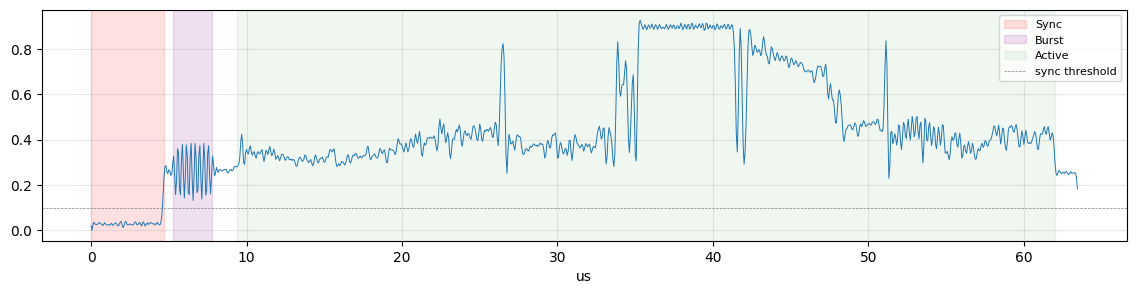

In [17]:
edge0 = int(hsync_edges[len(hsync_edges) // 2])
t = np.arange(SAMPLES_PER_LINE) / SAMPLE_RATE * 1e6

plt.figure(figsize=(14, 3))
plt.plot(t, composite[edge0:edge0 + SAMPLES_PER_LINE], lw=0.7)
plt.axvspan(0, HSYNC_DURATION_US, alpha=0.12, color='red', label='Sync')
plt.axvspan(BURST_START/SAMPLE_RATE*1e6, BURST_END/SAMPLE_RATE*1e6, alpha=0.12, color='purple', label='Burst')
plt.axvspan(ACTIVE_START/SAMPLE_RATE*1e6, ACTIVE_END/SAMPLE_RATE*1e6, alpha=0.06, color='green', label='Active')
plt.axhline(0.1, color='gray', lw=0.5, ls='--', label='sync threshold')
plt.xlabel('us'); plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.show()

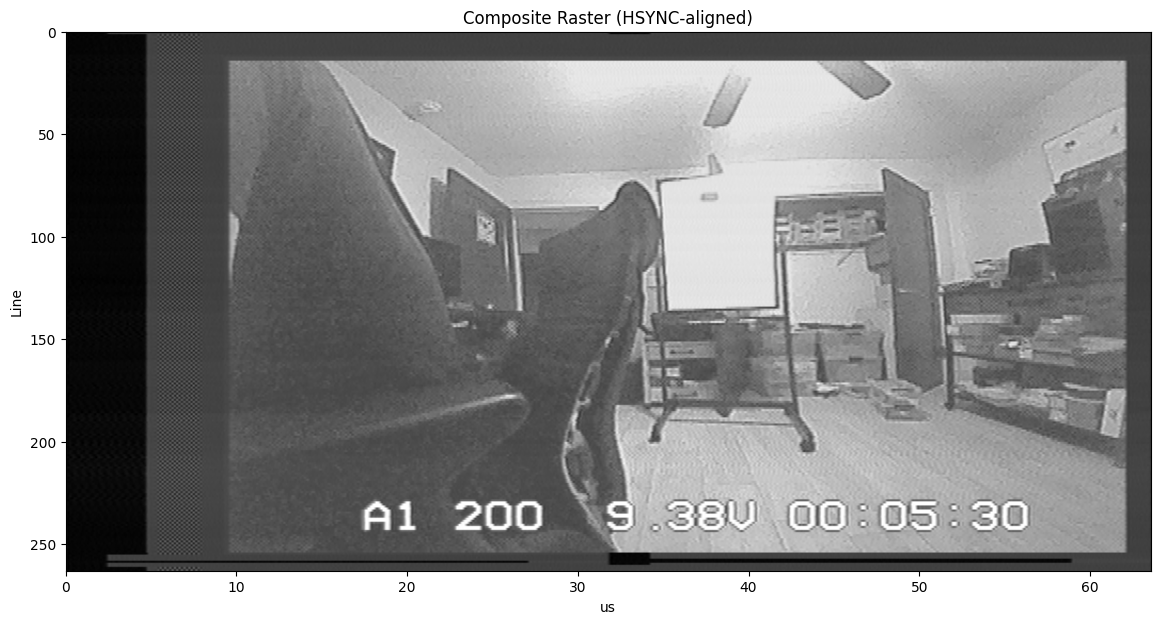

In [18]:
n = min(LINES_PER_FIELD, len(lines))
plt.figure(figsize=(14, 7))
plt.imshow(lines[:n], aspect='auto', cmap='gray', vmin=0, vmax=1,
           extent=[0, LINE_DURATION_US, n, 0])
plt.title('Composite Raster (HSYNC-aligned)'); plt.xlabel('us'); plt.ylabel('Line')
plt.show()

### Active Line Filter

In [19]:
active_idx = []
for i in range(len(lines)):
    if np.max(lines[i, ACTIVE_START:ACTIVE_END]) > BLACK + 0.05:
        active_idx.append(i)
active_idx = np.array(active_idx)

print(f"{len(lines)} lines, {len(active_idx)} active")

263 lines, 240 active


### Burst Phase

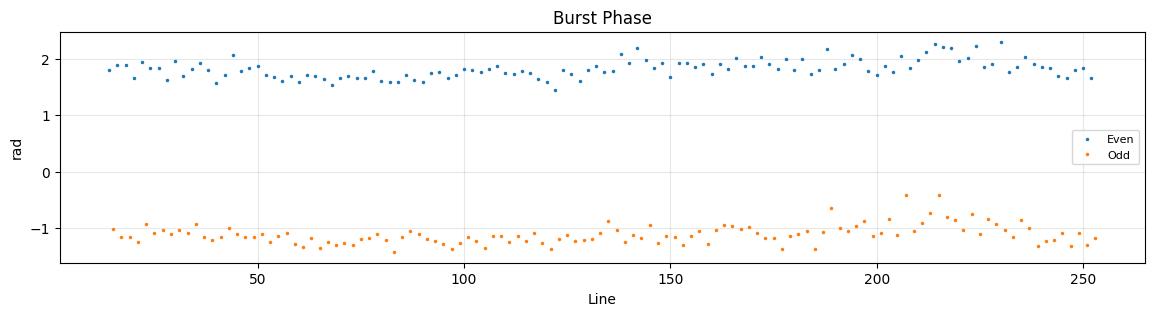

In [20]:
burst_phases = extract_burst_phase(lines)

even = active_idx[active_idx % 2 == 0]
odd  = active_idx[active_idx % 2 == 1]
plt.figure(figsize=(14, 3))
plt.plot(even, burst_phases[even], '.', ms=3, label='Even')
plt.plot(odd,  burst_phases[odd],  '.', ms=3, label='Odd')
plt.title('Burst Phase'); plt.ylabel('rad'); plt.xlabel('Line')
plt.legend(fontsize=8); plt.grid(True, alpha=0.3)
plt.show()

### Y/C Separation

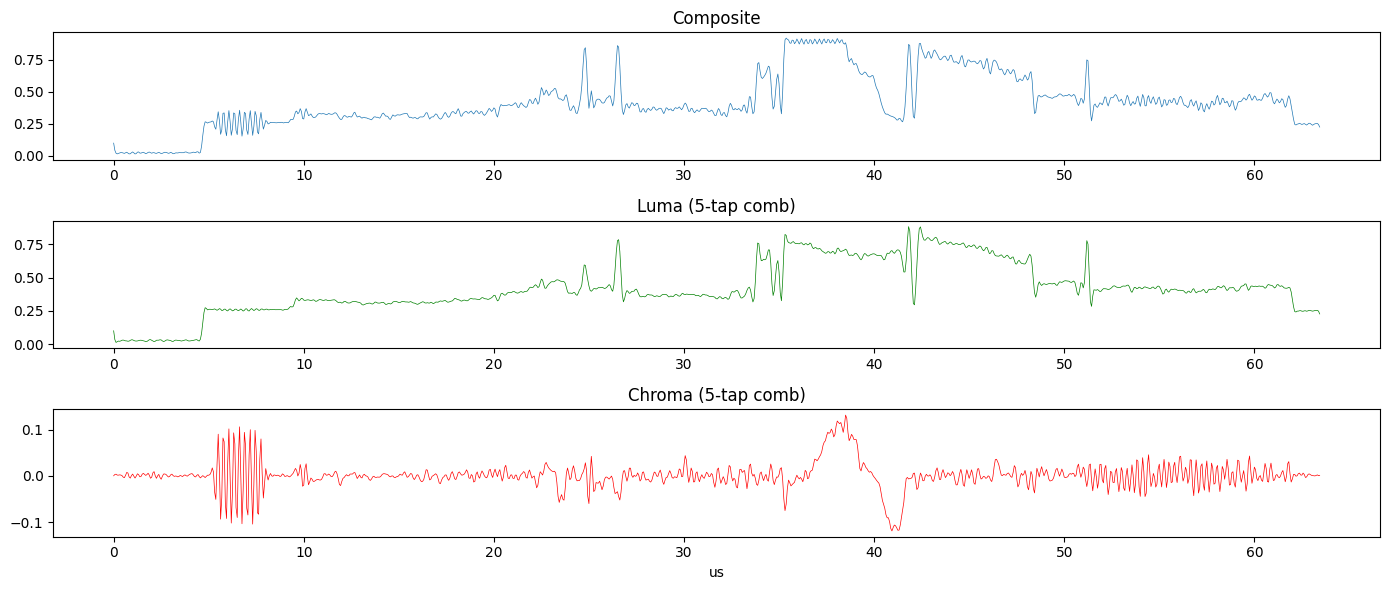

In [21]:
# 5-tap comb: smooths Y/C separation across 5 lines instead of 3.
luma   = np.zeros_like(lines)
chroma = np.zeros_like(lines)
for i in range(2, len(lines) - 2):
    luma[i]   = 0.125*lines[i-2] + 0.25*lines[i-1] + 0.25*lines[i] + 0.25*lines[i+1] + 0.125*lines[i+2]
    chroma[i] = 0.125*lines[i-2] - 0.25*lines[i-1] + 0.25*lines[i] - 0.25*lines[i+1] + 0.125*lines[i+2]
for i in (1, len(lines) - 2):
    luma[i]   =  0.25*lines[i-1] + 0.50*lines[i] + 0.25*lines[i+1]
    chroma[i] = -0.25*lines[i-1] + 0.50*lines[i] - 0.25*lines[i+1]
luma[0]  = lines[0]
luma[-1] = lines[-1]

dl = active_idx[len(active_idx) // 2]
t = np.arange(SAMPLES_PER_LINE) / SAMPLE_RATE * 1e6

fig, axes = plt.subplots(3, 1, figsize=(14, 6))
axes[0].plot(t, lines[dl], lw=0.5); axes[0].set_title('Composite')
axes[1].plot(t, luma[dl], lw=0.5, color='green'); axes[1].set_title('Luma (5-tap comb)')
axes[2].plot(t, chroma[dl], lw=0.5, color='red'); axes[2].set_title('Chroma (5-tap comb)')
axes[2].set_xlabel('us')
plt.tight_layout(); plt.show()

### QAM Demodulation

In [22]:
from scipy.signal import firwin
I_TAPS = firwin(25, cutoff=1.5e6, fs=SAMPLE_RATE, window=('kaiser', 6))
Q_TAPS = firwin(25, cutoff=0.5e6, fs=SAMPLE_RATE, window=('kaiser', 6))

I_ch, Q_ch = demodulate_iq(chroma, burst_phases, active_idx)

### Decoded Result

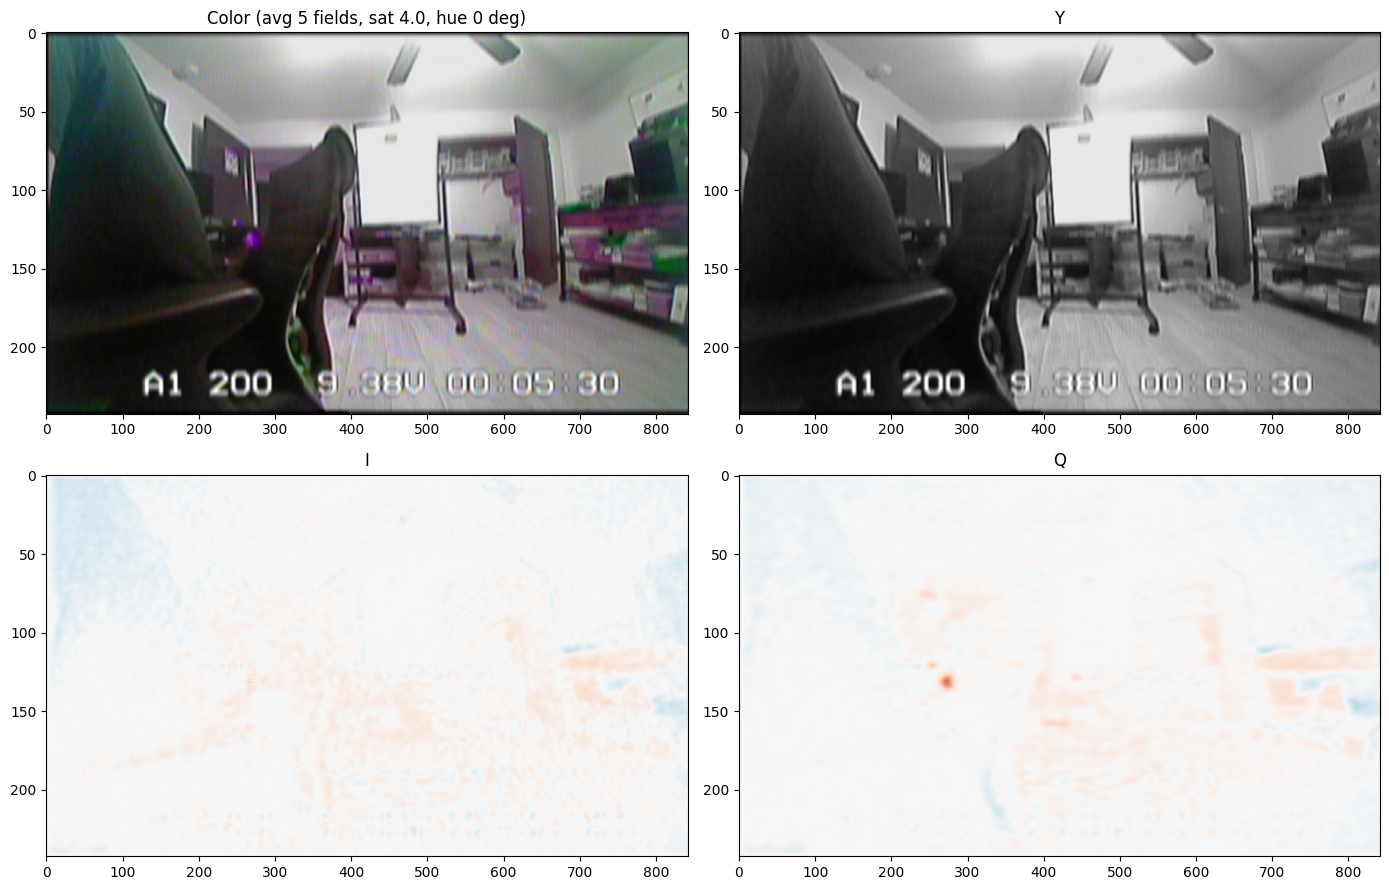

In [28]:
HUE        = 0.0
SATURATION = 4.0
N_FIELDS   = 5

b_chroma_bp, a_chroma_bp = butter(4, [2.0e6, 5.0e6], btype='band', fs=SAMPLE_RATE)

def decode_one_field(f_lines, f_blacks):
    f_active = np.array([i for i in range(LINES_PER_FIELD)
                         if np.max(f_lines[i, ACTIVE_START:ACTIVE_END]) > BLACK + 0.05])
    if len(f_active) < 100:
        return None

    f_bp = extract_burst_phase(f_lines)

    f_luma   = np.zeros_like(f_lines)
    f_chroma = np.zeros_like(f_lines)
    for i in range(2, LINES_PER_FIELD - 2):
        f_luma[i]   = 0.125*f_lines[i-2] + 0.25*f_lines[i-1] + 0.25*f_lines[i] + 0.25*f_lines[i+1] + 0.125*f_lines[i+2]
        f_chroma[i] = 0.125*f_lines[i-2] - 0.25*f_lines[i-1] + 0.25*f_lines[i] - 0.25*f_lines[i+1] + 0.125*f_lines[i+2]
    for i in (1, LINES_PER_FIELD - 2):
        f_luma[i]   =  0.25*f_lines[i-1] + 0.50*f_lines[i] + 0.25*f_lines[i+1]
        f_chroma[i] = -0.25*f_lines[i-1] + 0.50*f_lines[i] - 0.25*f_lines[i+1]
    f_luma[0]  = f_lines[0]
    f_luma[-1] = f_lines[-1]

    f_chroma = lfilter(b_chroma_bp, a_chroma_bp, f_chroma, axis=1)

    sc_norm = SUBCARRIER_FREQ / SAMPLE_RATE
    x       = np.arange(f_chroma.shape[1])
    gain    = 2.0 * SATURATION
    hue_rad = np.radians(HUE)
    f_I = np.zeros_like(f_chroma)
    f_Q = np.zeros_like(f_chroma)
    for li in f_active:
        carrier = f_bp[li] + hue_rad + 2 * np.pi * sc_norm * x
        f_I[li] = np.convolve(f_chroma[li] * np.cos(carrier) * gain, I_TAPS, mode='same')
        f_Q[li] = np.convolve(f_chroma[li] * np.sin(carrier) * gain, Q_TAPS, mode='same')

    return f_luma, f_chroma, f_I, f_Q, f_blacks

luma_sum  = np.zeros((LINES_PER_FIELD, SAMPLES_PER_LINE))
I_sum     = np.zeros((LINES_PER_FIELD, SAMPLES_PER_LINE))
Q_sum     = np.zeros((LINES_PER_FIELD, SAMPLES_PER_LINE))
black_sum = np.zeros(LINES_PER_FIELD)
n_fields = 0

for vs_fall in vsync_falling:
    if n_fields >= N_FIELDS:
        break
    later = np.where(all_hsync_edges >= int(vs_fall))[0]
    if len(later) == 0 or later[0] + LINES_PER_FIELD > len(all_lines):
        continue
    fsl = int(later[0])
    out = decode_one_field(all_lines[fsl:fsl + LINES_PER_FIELD],
                           all_black_levels[fsl:fsl + LINES_PER_FIELD])
    if out is None:
        continue
    f_luma, _, f_I, f_Q, f_blacks = out
    luma_sum  += f_luma
    I_sum     += f_I
    Q_sum     += f_Q
    black_sum += f_blacks
    n_fields  += 1

luma_avg  = luma_sum  / n_fields
I_avg     = I_sum     / n_fields
Q_avg     = Q_sum     / n_fields
black_avg = black_sum / n_fields

avg_active_idx = np.array([i for i in range(LINES_PER_FIELD)
                           if np.max(luma_avg[i, ACTIVE_START:ACTIVE_END]) > BLACK + 0.05])

rgb_image = decode_rgb(luma_avg, I_avg, Q_avg, black_avg, avg_active_idx)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

Y_img = np.zeros((len(avg_active_idx), ACTIVE_WIDTH))
for idx, li in enumerate(avg_active_idx):
    Y_img[idx] = np.clip((luma_avg[li, ACTIVE_START:ACTIVE_END] - black_avg[li]) / 0.7, 0, 1)

I_disp = I_avg[avg_active_idx][:, ACTIVE_START:ACTIVE_END]
Q_disp = Q_avg[avg_active_idx][:, ACTIVE_START:ACTIVE_END]

axes[0,0].imshow(rgb_image, aspect='auto')
axes[0,0].set_title(f'Color (avg {n_fields} fields, sat {SATURATION:.1f}, hue {HUE:.0f} deg)')
axes[0,1].imshow(Y_img, aspect='auto', cmap='gray', vmin=0, vmax=1)
axes[0,1].set_title('Y')
axes[1,0].imshow(I_disp, aspect='auto', cmap='RdBu_r', vmin=-0.6, vmax=0.6)
axes[1,0].set_title('I')
axes[1,1].imshow(Q_disp, aspect='auto', cmap='RdBu_r', vmin=-0.6, vmax=0.6)
axes[1,1].set_title('Q')

plt.tight_layout(); plt.show()

## References

[1] Proakis, J. G. & Salehi, M. *Digital Communications*. 5th ed. McGraw-Hill, 2008. <a name="ref1"></a>

[2] [*Analog Video 101*](http://www.ni.com/white-paper/4750/en/). National Instruments, 2018. <a name="ref2"></a>